In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('Parkison_Dataset.csv')


In [3]:
df

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,250,0,0.80903,0.56355,0.28385,417,416,0.004627,0.000052,0.00064,...,3.0706,3.0190,3.1212,2.4921,3.5844,3.5400,3.3805,3.2003,6.8671,0
752,250,0,0.16084,0.56499,0.59194,415,413,0.004550,0.000220,0.00143,...,1.9704,1.7451,1.8277,2.4976,5.2981,4.2616,6.3042,10.9058,28.4170,0
753,251,0,0.88389,0.72335,0.46815,381,380,0.005069,0.000103,0.00076,...,51.5607,44.4641,26.1586,6.3076,2.8601,2.5361,3.5377,3.3545,5.0424,0
754,251,0,0.83782,0.74890,0.49823,340,339,0.005679,0.000055,0.00092,...,19.1607,12.8312,8.9434,2.2044,1.9496,1.9664,2.6801,2.8332,3.7131,0


In [4]:
#veri kümesinin boyutunu kontrol eder
df.shape

(756, 755)

In [5]:
## Veri setindeki özelliklerin tiplerini ve eksik veri olup olmadığını kontrol edelim
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 755 entries, id to class
dtypes: float64(749), int64(6)
memory usage: 4.4 MB


In [6]:
# Veri setinin ilk 5 satırları
print(df.head())
#Bu veri seti, Parkinson hastalığı ile ilgili birçok özellik (PPE, DFA, RPDE vb.) ve son sütunda da sınıf etiketlerini (1 veya 0 olarak) içermektedir. 

   id  gender      PPE      DFA     RPDE  numPulses  numPeriodsPulses  \
0   0       1  0.85247  0.71826  0.57227        240               239   
1   0       1  0.76686  0.69481  0.53966        234               233   
2   0       1  0.85083  0.67604  0.58982        232               231   
3   1       0  0.41121  0.79672  0.59257        178               177   
4   1       0  0.32790  0.79782  0.53028        236               235   

   meanPeriodPulses  stdDevPeriodPulses  locPctJitter  ...  \
0          0.008064            0.000087       0.00218  ...   
1          0.008258            0.000073       0.00195  ...   
2          0.008340            0.000060       0.00176  ...   
3          0.010858            0.000183       0.00419  ...   
4          0.008162            0.002669       0.00535  ...   

   tqwt_kurtosisValue_dec_28  tqwt_kurtosisValue_dec_29  \
0                     1.5620                     2.6445   
1                     1.5589                     3.6107   
2          

In [7]:
# Eksik verileri kontrol edelim
print(df.isnull().sum())

id                           0
gender                       0
PPE                          0
DFA                          0
RPDE                         0
                            ..
tqwt_kurtosisValue_dec_33    0
tqwt_kurtosisValue_dec_34    0
tqwt_kurtosisValue_dec_35    0
tqwt_kurtosisValue_dec_36    0
class                        0
Length: 755, dtype: int64


In [8]:
# Sütun isimlerini kontrol edelim
print(df.columns)

Index(['id', 'gender', 'PPE', 'DFA', 'RPDE', 'numPulses', 'numPeriodsPulses',
       'meanPeriodPulses', 'stdDevPeriodPulses', 'locPctJitter',
       ...
       'tqwt_kurtosisValue_dec_28', 'tqwt_kurtosisValue_dec_29',
       'tqwt_kurtosisValue_dec_30', 'tqwt_kurtosisValue_dec_31',
       'tqwt_kurtosisValue_dec_32', 'tqwt_kurtosisValue_dec_33',
       'tqwt_kurtosisValue_dec_34', 'tqwt_kurtosisValue_dec_35',
       'tqwt_kurtosisValue_dec_36', 'class'],
      dtype='object', length=755)


In [9]:
df.isnull().sum() #özniteliklerin değer almadığı kaç satır var?

id                           0
gender                       0
PPE                          0
DFA                          0
RPDE                         0
                            ..
tqwt_kurtosisValue_dec_33    0
tqwt_kurtosisValue_dec_34    0
tqwt_kurtosisValue_dec_35    0
tqwt_kurtosisValue_dec_36    0
class                        0
Length: 755, dtype: int64

In [10]:
df.describe() #Veri kümesinin tanımlayıcı istatistiksel ölçümleri

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
count,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,...,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000
mean,125.500000,0.515873,0.746284,0.700414,0.489058,323.972222,322.678571,0.006360,0.000383,0.002324,...,26.237251,22.840337,18.587888,13.872018,12.218953,12.375335,14.799230,14.751559,31.481110,0.746032
std,72.793721,0.500079,0.169294,0.069718,0.137442,99.219059,99.402499,0.001826,0.000728,0.002628,...,42.220693,32.626464,25.537464,20.046029,17.783642,16.341665,15.722502,14.432979,34.230991,0.435568
min,0.000000,0.000000,0.041551,0.543500,0.154300,2.000000,1.000000,0.002107,0.000011,0.000210,...,1.509800,1.531700,1.582900,1.747200,1.789500,1.628700,1.861700,1.955900,2.364000,0.000000
25%,62.750000,0.000000,0.762833,0.647053,0.386537,251.000000,250.000000,0.005003,0.000049,0.000970,...,2.408675,3.452800,3.354825,3.077450,2.937025,3.114375,3.665925,3.741275,3.948750,0.000000
50%,125.500000,1.000000,0.809655,0.700525,0.484355,317.000000,316.000000,0.006048,0.000077,0.001495,...,5.586300,7.062750,6.077400,4.770850,4.300450,4.741450,6.725700,7.334250,10.637250,1.000000
75%,188.250000,1.000000,0.834315,0.754985,0.586515,384.250000,383.250000,0.007528,0.000171,0.002520,...,28.958075,29.830850,21.944050,13.188000,10.876150,12.201325,21.922050,22.495175,61.125325,1.000000
max,251.000000,1.000000,0.907660,0.852640,0.871230,907.000000,905.000000,0.012966,0.003483,0.027750,...,239.788800,203.311300,121.542900,102.207000,85.571700,73.532200,62.007300,57.544300,156.423700,1.000000


In [11]:
print(df.dtypes)

id                             int64
gender                         int64
PPE                          float64
DFA                          float64
RPDE                         float64
                              ...   
tqwt_kurtosisValue_dec_33    float64
tqwt_kurtosisValue_dec_34    float64
tqwt_kurtosisValue_dec_35    float64
tqwt_kurtosisValue_dec_36    float64
class                          int64
Length: 755, dtype: object


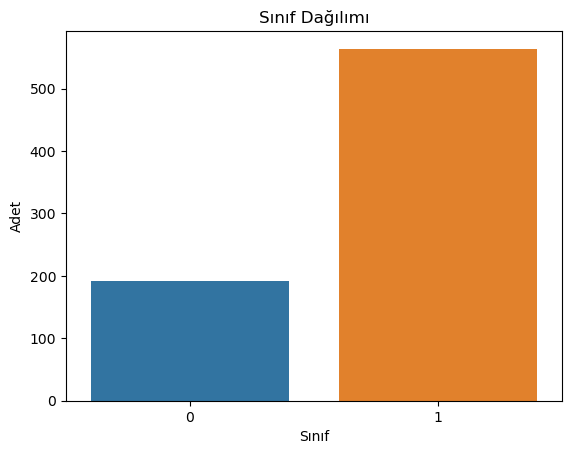

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sınıf dağılımını kontrol et
temp = df["class"].value_counts()
temp_df = pd.DataFrame({'class': temp.index, 'values': temp.values})

# Bar grafiğini oluştur
sns.barplot(x='class', y='values', data=temp_df)
plt.title('Sınıf Dağılımı')
plt.xlabel('Sınıf')
plt.ylabel('Adet')
plt.show()
#Veri dengesizliği.

def histplots(col):
    sns.histplot(df[col])
    plt.show()
for i in list(df.columns) [1:]:
    histplots(i)

In [13]:
# Bağımlı ve bağımsız değişkenleri ayırma
x = df.drop(["class", "id"], axis=1)
y = df["class"]

In [14]:
import imblearn
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler 
from collections import Counter

# Etiket dengesizliğini kontrol et
print("Orijinal sınıf dağılımı:", Counter(y))

Orijinal sınıf dağılımı: Counter({1: 564, 0: 192})


*Oversampling (Aşırı Örnekleme): Azınlık sınıflarından daha fazla örnek oluşturularak veri setinin dengeli hale getirilmesi. *Bu teknikler, modelin eğitiminde kullanılan veri setinin dengeli olmasını sağlar ve böylece modelin performansı artırılabilir. *RandomOverSampler kullanarak veri setimizi dengelediğimizde, azınlık sınıflarından daha fazla örnek ekleyerek sınıflar arası dengesizliği düzeltiriz.

In [15]:
from imblearn.over_sampling import RandomOverSampler
# Over-sampling ile dengesizliği düzeltme
ros = RandomOverSampler(random_state=42)
x_resampled, y_resampled = ros.fit_resample(x, y)

# Yeni etiket dağılımını kontrol et
print("Resampled sınıf dağılımı:", Counter(y_resampled))

Resampled sınıf dağılımı: Counter({1: 564, 0: 564})


In [16]:
# Veriyi MinMaxScaler ile ölçeklendirme
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_resampled)

PCA (Principal Component Analysis) kullanarak veri setinin boyutunu azaltmak için kullanılıyor. PCA, veri setindeki varyansı en iyi şekilde koruyarak daha az sayıda bileşenle veri setini temsil etmeyi sağlar. Bu, özellikle çok sayıda özelliğe (feature) sahip veri setlerinde model performansını artırmak ve işlem süresini azaltmak için yaygın olarak kullanılır.

In [17]:
from sklearn.decomposition import PCA

# %95 varyansı korumak
pca = PCA(n_components=0.95)  # %95 varyansı koruyacak bileşen sayısını belirler
X_PCA = pca.fit_transform(x_scaled)

#Orijinal ve Dönüştürülmüş Veri Setinin Şekillerinin Yazdırılması:
print(x_scaled.shape)
print(X_PCA.shape)

(1128, 753)
(1128, 108)


In [18]:
# Veri setini eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_PCA, y_resampled, test_size=0.2, random_state=7, shuffle=True)

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
list_met=[]
list_accuracy=[]

In [19]:
#Algorythms
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.ensemble import VotingClassifier
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
import numpy as np
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

             Method Used  Accuracy
0    Logistic Regression  0.849558
1          Decision Tree  0.915929
2                    SVM  0.951327
3                    KNN  0.920354
4   Gaussian Naive Bayes  0.778761
5  Bernoulli Naive Bayes  0.818584


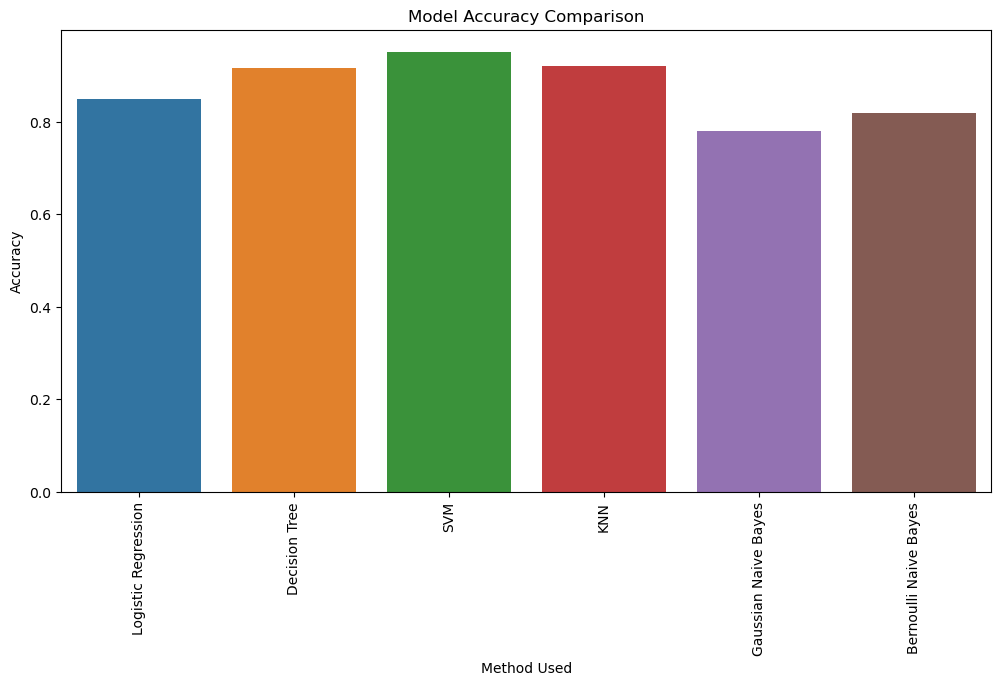

In [20]:

# Logistic Regression
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(C=0.4, max_iter=1000, solver='liblinear')
lr = classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_LR = accuracy_score(y_test, y_pred)

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
classifier2 = DecisionTreeClassifier(random_state=14)
dt = classifier2.fit(X_train, y_train)
# Prediction
y_pred2 = classifier2.predict(X_test)
# Accuracy
accuracy_DT = accuracy_score(y_test, y_pred2)

# SVM
from sklearn.svm import SVC
model_svm = SVC(cache_size=100)
svm = model_svm.fit(X_train, y_train)
# Prediction
y_pred3 = model_svm.predict(X_test)
# Accuracy
accuracy_svc = accuracy_score(y_test, y_pred3)

# KNN
from sklearn.neighbors import KNeighborsClassifier
model_knn3 = KNeighborsClassifier(n_neighbors=3)
knn = model_knn3.fit(X_train, y_train)
# Predicting Test Set N-3
pred_knn3 = model_knn3.predict(X_test)
# Accuracy
accuracy_KNN = accuracy_score(y_test, pred_knn3)

# Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb = gnb.fit(X_train, y_train)
# Predicting Test Set
pred_gnb = gnb.predict(X_test)
# Accuracy
accuracy_GNB = accuracy_score(y_test, pred_gnb)

# Bernoulli Naive Bayes
from sklearn.naive_bayes import BernoulliNB
bnb = BernoulliNB()
bnb = bnb.fit(X_train, y_train)
# Predicting Test Set
pred_bnb = bnb.predict(X_test)
# Accuracy
accuracy_BNB = accuracy_score(y_test, pred_bnb)

# List of methods and their accuracies
list1 = ['Logistic Regression', 'Decision Tree', 'SVM', 'KNN', 'Gaussian Naive Bayes', 'Bernoulli Naive Bayes']
list2 = [accuracy_LR, accuracy_DT, accuracy_svc, accuracy_KNN, accuracy_GNB, accuracy_BNB]
list3 = [classifier, classifier2, model_svm, model_knn3, gnb, bnb]

df_Accuracy = pd.DataFrame({'Method Used': list1, 'Accuracy': list2})
print(df_Accuracy)

# Plotting the results
plt.figure(figsize=(12, 6))
chart = sns.barplot(x="Method Used", y="Accuracy", data=df_Accuracy)
chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
chart.set_title('Model Accuracy Comparison')
chart.set_xlabel('Method Used')
chart.set_ylabel('Accuracy')

plt.show()


             Method Used  Accuracy
0    Logistic Regression  0.849558
1          Decision Tree  0.915929
2                    SVM  0.951327
3                    KNN  0.920354
4   Gaussian Naive Bayes  0.778761
5  Bernoulli Naive Bayes  0.818584
6          Random Forest  0.951327


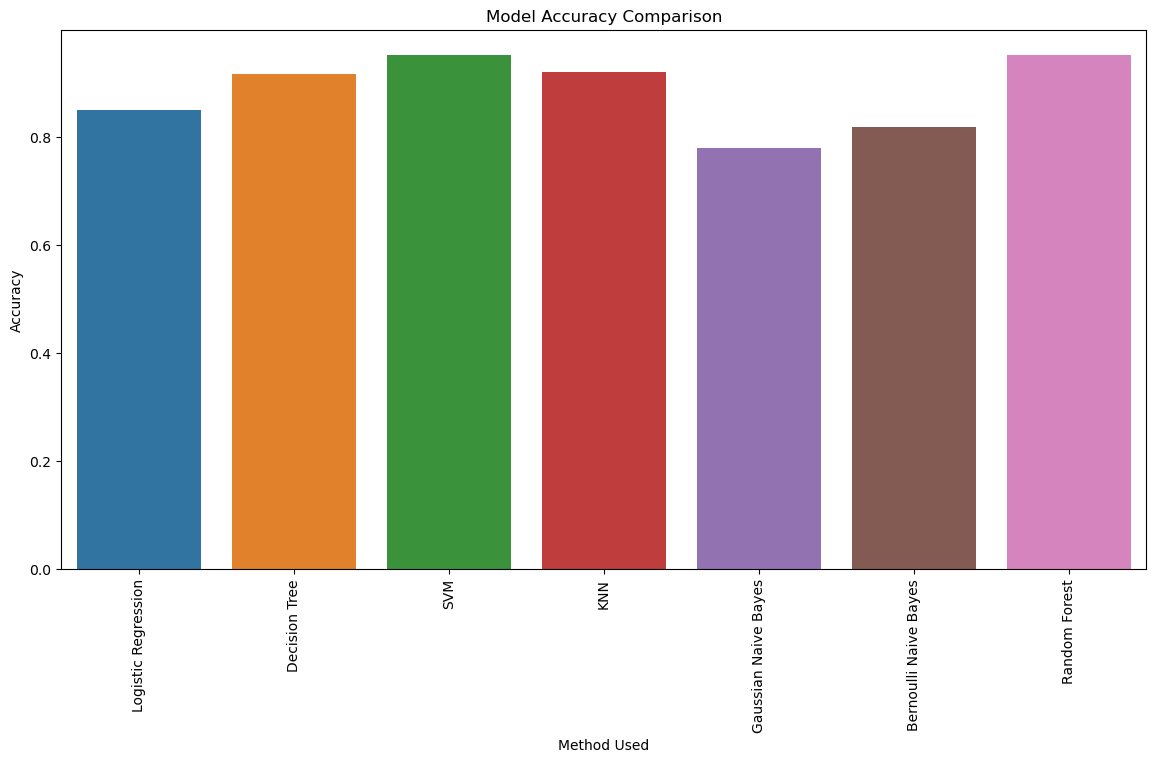

In [21]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(C=0.4, max_iter=1000, solver='liblinear')
lr = classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_LR = accuracy_score(y_test, y_pred)

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
classifier2 = DecisionTreeClassifier(random_state=14)
dt = classifier2.fit(X_train, y_train)
# Prediction
y_pred2 = classifier2.predict(X_test)
# Accuracy
accuracy_DT = accuracy_score(y_test, y_pred2)

# SVM
from sklearn.svm import SVC
model_svm = SVC(cache_size=100)
svm = model_svm.fit(X_train, y_train)
# Prediction
y_pred3 = model_svm.predict(X_test)
# Accuracy
accuracy_svc = accuracy_score(y_test, y_pred3)

# KNN
from sklearn.neighbors import KNeighborsClassifier
model_knn3 = KNeighborsClassifier(n_neighbors=3)
knn = model_knn3.fit(X_train, y_train)
# Predicting Test Set N-3
pred_knn3 = model_knn3.predict(X_test)
# Accuracy
accuracy_KNN = accuracy_score(y_test, pred_knn3)

# Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb = gnb.fit(X_train, y_train)
# Predicting Test Set
pred_gnb = gnb.predict(X_test)
# Accuracy
accuracy_GNB = accuracy_score(y_test, pred_gnb)

# Bernoulli Naive Bayes
from sklearn.naive_bayes import BernoulliNB
bnb = BernoulliNB()
bnb = bnb.fit(X_train, y_train)
# Predicting Test Set
pred_bnb = bnb.predict(X_test)
# Accuracy
accuracy_BNB = accuracy_score(y_test, pred_bnb)

# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(criterion='entropy', random_state=14)
rf = rf.fit(X_train, y_train)
# Predicting Test Set
pred_rf = rf.predict(X_test)
# Accuracy
accuracy_RF = accuracy_score(y_test, pred_rf)

# List of methods and their accuracies
list1 = ['Logistic Regression', 'Decision Tree', 'SVM', 'KNN', 'Gaussian Naive Bayes', 'Bernoulli Naive Bayes', 'Random Forest']
list2 = [accuracy_LR, accuracy_DT, accuracy_svc, accuracy_KNN, accuracy_GNB, accuracy_BNB, accuracy_RF]
list3 = [classifier, classifier2, model_svm, model_knn3, gnb, bnb, rf]

df_Accuracy = pd.DataFrame({'Method Used': list1, 'Accuracy': list2})
print(df_Accuracy)

# Plotting the results
plt.figure(figsize=(14, 7))
chart = sns.barplot(x="Method Used", y="Accuracy", data=df_Accuracy)
chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
chart.set_title('Model Accuracy Comparison')
chart.set_xlabel('Method Used')
chart.set_ylabel('Accuracy')

plt.show()


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Fit the Random Forest model
model_rf = RandomForestClassifier(criterion='entropy', random_state=14)
model_rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = model_rf.predict(X_test)

# Evaluate the Random Forest model
accuracy_RF = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_RF)


Random Forest Accuracy: 0.9513274336283186


Random Forest Accuracy: 0.9513274336283186
Bagging Accuracy: 0.9380530973451328
AdaBoost Accuracy: 0.9292035398230089
             Method Used  Accuracy
0    Logistic Regression  0.849558
1          Decision Tree  0.915929
2                    SVM  0.951327
3                    KNN  0.920354
4   Gaussian Naive Bayes  0.778761
5  Bernoulli Naive Bayes  0.818584
6          Random Forest  0.951327
7                Bagging  0.938053
8               AdaBoost  0.929204


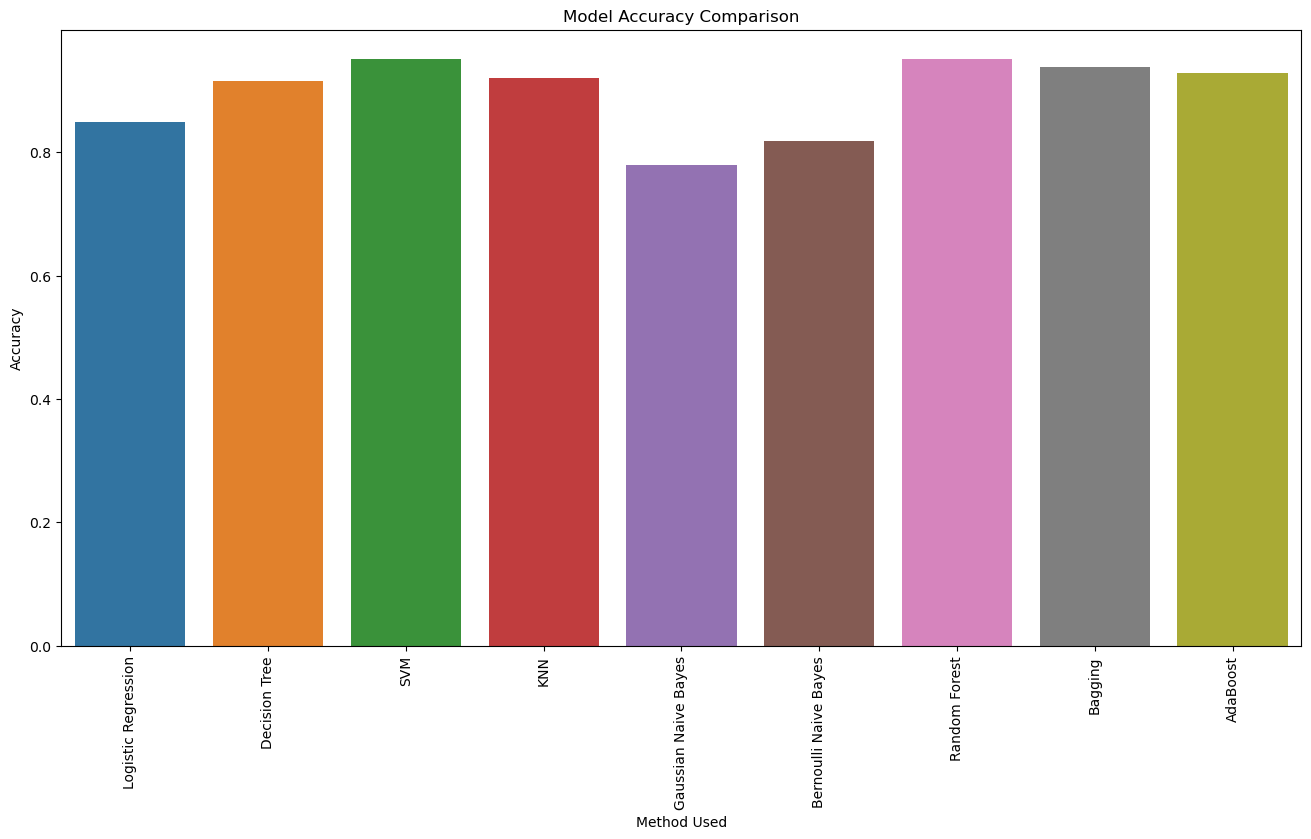

In [23]:
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Fit the Random Forest model
model_rf = RandomForestClassifier(criterion='entropy', random_state=14)
model_rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = model_rf.predict(X_test)

# Evaluate the Random Forest model
accuracy_RF = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_RF)

# Bagging
bagging = BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=50, random_state=14)
bagging.fit(X_train, y_train)
# Make predictions
y_pred_bagging = bagging.predict(X_test)
# Evaluate the Bagging model
accuracy_Bagging = accuracy_score(y_test, y_pred_bagging)
print("Bagging Accuracy:", accuracy_Bagging)

# AdaBoost
adaboost = AdaBoostClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=50, random_state=14)
adaboost.fit(X_train, y_train)
# Make predictions
y_pred_adaboost = adaboost.predict(X_test)
# Evaluate the AdaBoost model
accuracy_AdaBoost = accuracy_score(y_test, y_pred_adaboost)
print("AdaBoost Accuracy:", accuracy_AdaBoost)

# List of methods and their accuracies
list1 = ['Logistic Regression', 'Decision Tree', 'SVM', 'KNN', 'Gaussian Naive Bayes', 'Bernoulli Naive Bayes', 'Random Forest', 'Bagging', 'AdaBoost']
list2 = [accuracy_LR, accuracy_DT, accuracy_svc, accuracy_KNN, accuracy_GNB, accuracy_BNB, accuracy_RF, accuracy_Bagging, accuracy_AdaBoost]
list3 = [classifier, classifier2, model_svm, model_knn3, gnb, bnb, model_rf, bagging, adaboost]

df_Accuracy = pd.DataFrame({'Method Used': list1, 'Accuracy': list2})
print(df_Accuracy)

# Plotting the results
plt.figure(figsize=(16, 8))
chart = sns.barplot(x="Method Used", y="Accuracy", data=df_Accuracy)
chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
chart.set_title('Model Accuracy Comparison')
chart.set_xlabel('Method Used')
chart.set_ylabel('Accuracy')

plt.show()


In [24]:
from sklearn.metrics import confusion_matrix

# Fit the Logistic Regression model
classifier = LogisticRegression(C=0.4, max_iter=1000, solver='liblinear')
classifier.fit(X_train, y_train)

# Make predictions
y_pred = classifier.predict(X_test)

# Evaluate the model
accuracy_LR = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", accuracy_LR)

# Generate the classification report
from sklearn.metrics import classification_report
print('Classification Report:')
print(classification_report(y_test, y_pred))

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)


Logistic Regression Accuracy: 0.8495575221238938
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       119
           1       0.82      0.87      0.85       107

    accuracy                           0.85       226
   macro avg       0.85      0.85      0.85       226
weighted avg       0.85      0.85      0.85       226

Confusion Matrix:
[[99 20]
 [14 93]]


In [25]:
from sklearn.metrics import classification_report, confusion_matrix

# List of models
models = [classifier, classifier2, model_svm, model_knn3, gnb, bnb, model_rf, bagging, adaboost]
model_names = ['Logistic Regression', 'Decision Tree', 'SVM', 'KNN', 'Gaussian Naive Bayes', 'Bernoulli Naive Bayes', 'Random Forest', 'Bagging', 'AdaBoost']

# Iterate over models
for model, name in zip(models, model_names):
    print("********************* ", name, " ********************* ")
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Print classification report
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
    
    # Print confusion matrix
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print()


*********************  Logistic Regression  ********************* 
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       119
           1       0.82      0.87      0.85       107

    accuracy                           0.85       226
   macro avg       0.85      0.85      0.85       226
weighted avg       0.85      0.85      0.85       226

Confusion Matrix:
[[99 20]
 [14 93]]

*********************  Decision Tree  ********************* 
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       119
           1       0.93      0.89      0.91       107

    accuracy                           0.92       226
   macro avg       0.92      0.91      0.92       226
weighted avg       0.92      0.92      0.92       226

Confusion Matrix:
[[112   7]
 [ 12  95]]

*********************  SVM  ********************* 
Classification Report:
              prec

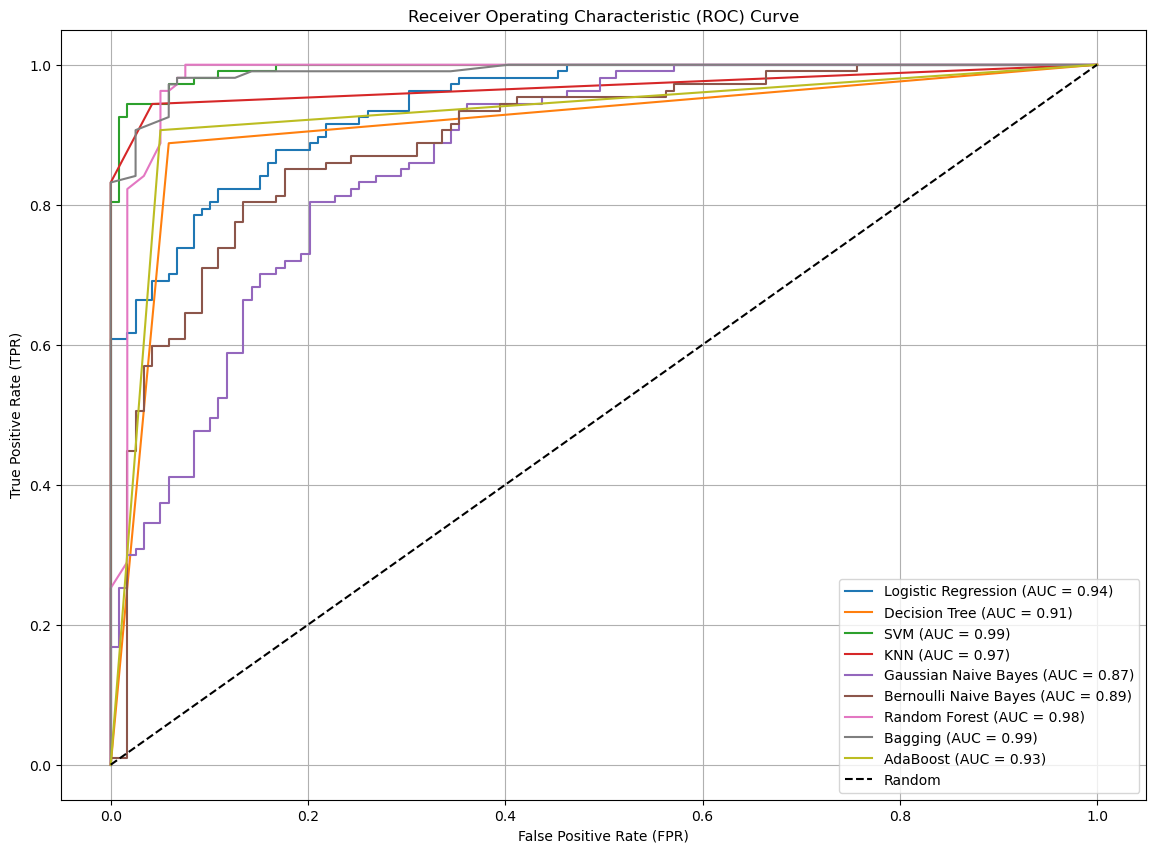

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier

# Define and fit models
models = [
    LogisticRegression(C=0.4, max_iter=1000, solver='liblinear'),
    DecisionTreeClassifier(random_state=14),
    SVC(probability=True, cache_size=100),  # Enable probability estimates
    KNeighborsClassifier(n_neighbors=3),
    GaussianNB(),
    BernoulliNB(),
    RandomForestClassifier(criterion='entropy', random_state=14),
    BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=50, random_state=14),
    AdaBoostClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=50, random_state=14)
]

model_names = [
    'Logistic Regression', 
    'Decision Tree', 
    'SVM', 
    'KNN', 
    'Gaussian Naive Bayes', 
    'Bernoulli Naive Bayes', 
    'Random Forest', 
    'Bagging', 
    'AdaBoost'
]

# Fit models
for model in models:
    model.fit(X_train, y_train)

# Plot ROC curve for each model
plt.figure(figsize=(14, 10))

for model, name in zip(models, model_names):
    # Make predictions and compute ROC curve
    y_pred_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for positive class
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot diagonal line for random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random')

# Formatting
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()
